### Model Interpretability

- [Model Interpretability](#Model-Interpretability)

**1. SHAP (SHapley Additive exPlanations)** SHAP computes the marginal contribution of each feature across all possible feature subsets (coalitions).

> How much did each feature push this specific prediction away from the baseline average prediction?' It uses game theory to guarantee fair credit allocation among features.

Imagine 3 friends—Credit Score, Income, and Debt—working together to set a loan interest rate. Baseline (Average Interest Rate): $10\%$ Actual Model Prediction for Customer X: $16\%$ Difference to Explain: $+6\%$ How do we split that $+6\%$ among the three features fairly?

How It Works Step-by-Step (The Coalition Math) SHAP tests what happens when you add Income to different combinations (coalitions) of other features:
1. Model prediction with [No features]: $10\%$ (Base value)
2. Model prediction with [Credit Score]: $12\%$
3. Model prediction with [Credit Score + Income]: $15\%$ $\rightarrow$ Income added $+3\%$ here.
4. Model prediction with [Debt]: $11\%$
5. Model prediction with [Debt + Income]: $13\%$ $\rightarrow$ Income added $+2\%$ here.

SHAP calculates the marginal contribution of Income across all possible combinations and takes a weighted average.$$\text{Final Prediction} = \text{Base Value} + \sum \text{SHAP Values}$$

Base Value: 10% ──► [+2% Credit Score] ──► [+3% Debt] ──► [+1% Income] ──► Final: 16%

```
SHAP Waterfall Plot (Individual Prediction)
                  
  f(x) = 16% (Final Prediction) ──────────────────────────────┐
                                                              │
  Debt = $15k             [======= RED (+3%) =======>]        │
  Credit Score = 580      [==== RED (+2%) ====>]              │
  Income = $45k           [== RED (+1%) ==>]                  │
  Age = 42                [<-- BLUE (-0.5%) --]               │
                                                              │
  E[f(x)] = 10% (Base Average Value) ─────────────────────────┘
  
```
_B. Global Explanation: SHAP Beeswarm Plot_


```

SHAP Beeswarm Plot (Global Dataset)

  Feature Name         Low ◄──────── Feature Value ────────► High
  ─────────────────────────────────────────────────────────────────
  Debt             •••  •   •••••   •••••••••••••••••••••••••  (Red)
  Credit Score     (Red) ••••••••••••••••••••••   •   •••      (Blue)
  Income           (Red) ••••••••••••   ••••••••••••          (Blue)
                   ────────────────────────────────────────────────
                   -5%            0%           +5%
                           SHAP Value (Impact on Prediction)
```

1. Vertical Axis (Y-axis): Features are ranked top-to-bottom by global importance (most important feature at the top).
2. Horizontal Axis (X-axis): Shows the SHAP Value (impact on prediction). Points to the right of $0$ increased the prediction; points to the left lowered it.
3. Coloring (Feature Value):Red dots: High feature values (e.g., high debt, high credit score).Blue dots: Low feature values (e.g., low debt, low credit score).
4. Pattern Interpretation:Look at Debt at the top: High values (Red) cluster on the right ($+5\%$), meaning high debt consistently increases interest rates.Look at Credit Score: High values (Red) cluster on the left ($-5\%$), meaning a high credit score consistently lowers interest rates.

**2. LIME (Local Interpretable Model-Agnostic Explanations)** LIME approximates a complex global decision boundary locally around a target prediction $x$ using a simpler, interpretable surrogate model $g$ (e.g., a sparse linear regression model

> Why did the model make this specific prediction right here?' It ignores the global decision boundary and fits a simple, interpretable linear model locally around a single prediction point.

LIME zooms into Customer X's neighborhood, draws a local straight line, and reads the coefficients.

How It Works Step-by-StepTarget Instance: 
1. Take Customer X (Income: $50k, Age: 30, Debt: $10k).
2. Perturb Data: Create 1,000 synthetic variations by tweaking values (e.g., Income: $52k, Age: 29, Debt: $12k).
3. Get Black-Box Predictions: Pass these 1,000 synthetic points through the complex model.4. Weight Samples: Give higher importance (weight) to points close to Customer X, and low weight to far-away points.
5. Fit Sparse Linear Model: Train a simple Linear Regression on the weighted synthetic points.
6. Interpret Coefficients: "For Customer X, every $1k increase in Debt lowered approval probability by $4\%$."

**3. Partial Dependence Plot (PDP):** Shows the marginal effect one or two features have on the predicted outcome of a machine learning model.$$\bar{f}_{S}(x_S) = \frac{1}{N}\sum_{i=1}^N f(x_S, x_{C, i})$$Pitfall: Assumes features $x_S$ and background features $x_C$ are uncorrelated. If correlated, PDP evaluates unrealistic synthetic data combinations.

> On average across the entire dataset, how does changing feature $X$ affect the predicted outcome $Y$?

You want to know how Property Square Footage affects House Price predictions in your model, holding everything else constant on average.

How It Works Step-by-Step - To compute the PDP value for Square Footage = 2000 sq ft - 
1. Take your dataset of 1,000 houses.
2. Overwrite the Square Footage column for ALL 1,000 houses to 2000 sq ft, leaving bedrooms, location, and age untouched.
3. Pass all 1,000 modified houses through the model and record predictions.
4. Take the average prediction.
5. Repeat for 2500 sq ft, 3000 sq ft, etc., and plot the curve.$$\bar{f}_{S}(x_S) = \frac{1}{N}\sum_{i=1}^N f(x_S, \mathbf{x}_{C, i})$$

/Users/monusingh/work-share/code-blogs-articles/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


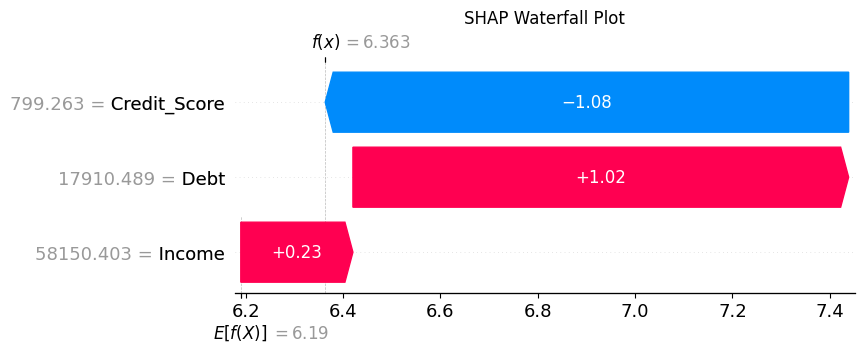

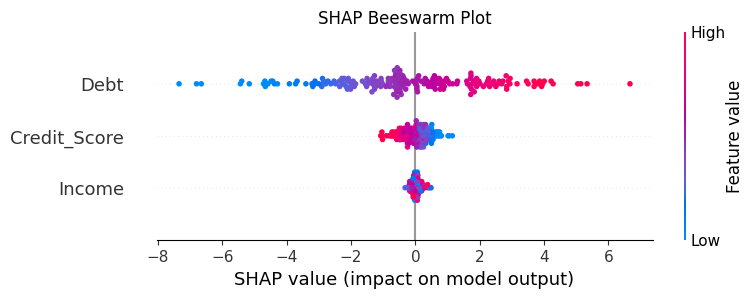

/Users/monusingh/work-share/code-blogs-articles/.venv/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/monusingh/work-share/code-blogs-articles/.venv/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/monusingh/work-share/code-blogs-articles/.venv/lib/python3.12/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future vers

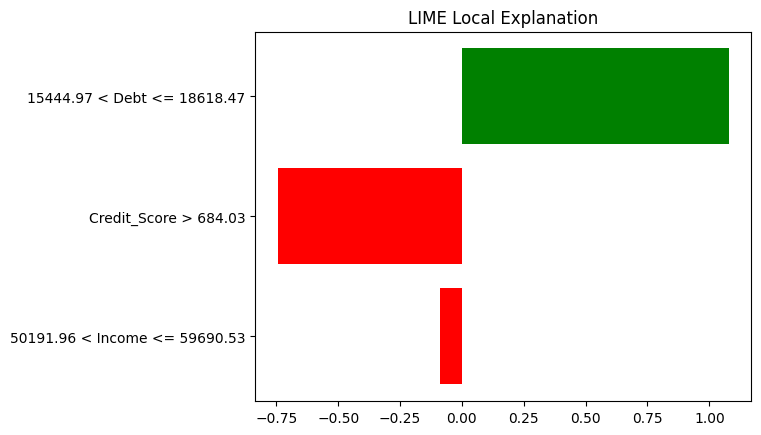

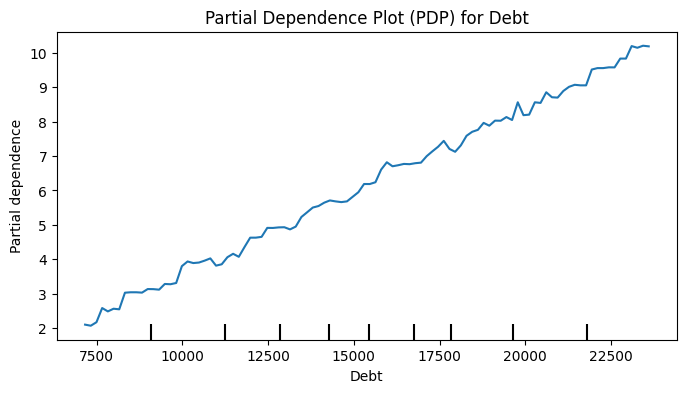

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split

# 1. Create synthetic dataset
np.random.seed(42)
n_samples = 1000
data = pd.DataFrame({
    'Income': np.random.normal(50000, 15000, n_samples),
    'Debt': np.random.normal(15000, 5000, n_samples),
    'Credit_Score': np.random.normal(650, 50, n_samples)
})
# Target: Higher debt and lower score increase interest rate
target = 5 + (data['Debt'] / 2000) - (data['Credit_Score'] / 100) + np.random.normal(0, 0.5, n_samples)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# 2. Train XGBoost Model
model = xgb.XGBRegressor().fit(X_train, y_train)

# --- A. GENERATE SHAP PLOTS ---
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Plot 1: SHAP Waterfall (Individual)
plt.title("SHAP Waterfall Plot")
shap.plots.waterfall(shap_values[0], show=False)
plt.show()

# Plot 2: SHAP Beeswarm (Global)
plt.title("SHAP Beeswarm Plot")
shap.plots.beeswarm(shap_values, show=False)
plt.show()

# --- B. GENERATE LIME PLOT ---
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression'
)
exp = lime_explainer.explain_instance(X_test.iloc[0], model.predict)
exp.as_pyplot_figure()
plt.title("LIME Local Explanation")
plt.show()

# --- C. GENERATE PDP PLOT ---
fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(model, X_train, features=['Debt'], ax=ax)
plt.title("Partial Dependence Plot (PDP) for Debt")
plt.show()